# EE-411 Lottery Ticket Hypothesis - Figures: Resnet-18 + Iterative + Random Init

**Author:** Tianrui (Jerry)
**Model:** ResNet 18
**Dataset:** [CIFAR-10]  
**Date:** [2026.01.12]

---

## Instructions

1. **Define your model** in the "Model Definition" section
2. **Train baseline model** to get initial performance
3. **Run pruning experiments** using the shared pruning algorithms
4. **Visualize and analyze** your results
5. **Save your results** to the `results/` folder

## Quick Links

- [Paper](https://arxiv.org/abs/1803.03635): "The Lottery Ticket Hypothesis"
- [Shared Code](../../shared/): Training utils and pruning algorithms
- [Results](../../results/): Save checkpoints and figures here

## Setup Run ID

In [1]:
import os
import time
from datetime import datetime

# 1. Generate a unique Run ID (Model + Timestamp)
# e.g., "resnet20_20231027_153045"
model_name = "resnet20_create_figures"  # Or "resnet18"
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
run_id = f"{model_name}_{timestamp}"

# 2. Create specific directories for THIS run
# Instead of dumping everything in 'results/', we make a subfolder
base_dir = "../../results"
run_dir = os.path.join(base_dir, run_id)
ckpt_dir = os.path.join(run_dir, "checkpoints")
fig_dir = os.path.join(run_dir, "figures")

os.makedirs(ckpt_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

print(f"Experiment Initialized: {run_id}")
print(f"Results will be saved to: {run_dir}")

Experiment Initialized: resnet20_create_figures_20260112_102540
Results will be saved to: ../../results/resnet20_create_figures_20260112_102540


## 1. Setup and Imports

In [2]:
import sys
sys.path.append('../..')  # Add project root to path

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

# Import shared utilities
from shared.training_utils import fit, predict
from shared.pruning import (
    iterative_pruning,
    one_shot_pruning,
    one_shot_pruning_efficient,
    random_reinit_pruning,
    get_pruning_config,
    count_parameters,
    evaluate_model,
    apply_mask,
    create_global_mask
)

# Fix random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Generate Figures

Loading Data...
Figure saved to ../../results/resnet20_create_figures_20260112_102540/figures/reproduced_figure_8_resnet20_create_figures_20260112_102540.png


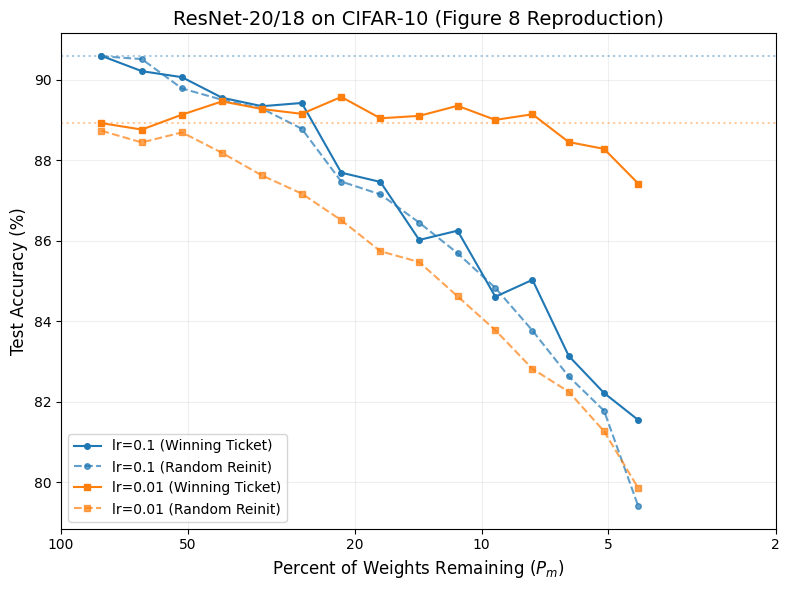

In [3]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 1. 定义文件路径 (请根据实际情况微调路径)
# ==========================================
# Group 1: Learning Rate = 0.1
path_iter_01 = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"
path_rand_01 = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints/random_init_results__resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"

# Group 2: Learning Rate = 0.01
path_iter_001 = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.01_20260111_205802.pth"
path_rand_001 = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/random_init_results_matched.pth"

# ==========================================
# 2. 数据提取函数
# ==========================================
def load_and_extract(path):
    if not os.path.exists(path):
        print(f"Error: File not found: {path}")
        return [], []
    
    # 加载 Checkpoint
    # map_location='cpu' 防止在没有 GPU 的机器上报错
    checkpoint = torch.load(path, map_location='cpu')
    
    # 兼容不同的保存格式 (有些直接存 list, 有些存 dict['results'])
    if isinstance(checkpoint, dict) and 'results' in checkpoint:
        results = checkpoint['results']
    else:
        results = checkpoint # 假设直接是 list
        
    x_list = []
    y_list = []
    
    for res in results:
        # 获取剩余参数百分比 (X轴)
        pct = res.get('remaining_params_pct', None)
        # 获取测试集准确率 (Y轴)
        acc = res.get('test_accuracy', None)
        
        if pct is not None and acc is not None:
            x_list.append(pct)
            y_list.append(acc) # 已经是百分比了 (0-100)
            
    return np.array(x_list), np.array(y_list)

# ==========================================
# 3. 加载数据
# ==========================================
print("Loading Data...")
x_iter_01, y_iter_01 = load_and_extract(path_iter_01)
x_rand_01, y_rand_01 = load_and_extract(path_rand_01)

x_iter_001, y_iter_001 = load_and_extract(path_iter_001)
x_rand_001, y_rand_001 = load_and_extract(path_rand_001)

# ==========================================
# 4. 绘图 (仿照 Figure 8 风格)
# ==========================================
plt.figure(figsize=(8, 6))

# --- 样式设置 ---
# 定义颜色和线型
color_01 = 'tab:blue'    # LR=0.1 用蓝色
color_001 = 'tab:orange' # LR=0.01 用橙色
# 预留给 Warmup (LR=0.03) 的颜色，等你跑完了可以加
color_warmup = 'tab:green' 

# --- 绘制 LR = 0.1 ---
# Winning Ticket (Iterative) -> 实线, 圆点
plt.plot(x_iter_01, y_iter_01, label='lr=0.1 (Winning Ticket)', 
         color=color_01, linestyle='-', marker='o', markersize=4)

# Random Reinit -> 虚线, 叉号或圆点
plt.plot(x_rand_01, y_rand_01, label='lr=0.1 (Random Reinit)', 
         color=color_01, linestyle='--', marker='o', markersize=4, alpha=0.7)

# --- 绘制 LR = 0.01 ---
# Winning Ticket (Iterative)
plt.plot(x_iter_001, y_iter_001, label='lr=0.01 (Winning Ticket)', 
         color=color_001, linestyle='-', marker='s', markersize=4)

# Random Reinit
plt.plot(x_rand_001, y_rand_001, label='lr=0.01 (Random Reinit)', 
         color=color_001, linestyle='--', marker='s', markersize=4, alpha=0.7)

# --- 绘制基准线 (Baseline) ---
# 画出 100% 参数时的准确率水平线，方便对比
if len(y_iter_01) > 0:
    plt.axhline(y=y_iter_01[0], color=color_01, linestyle=':', alpha=0.4)
if len(y_iter_001) > 0:
    plt.axhline(y=y_iter_001[0], color=color_001, linestyle=':', alpha=0.4)

# --- 坐标轴设置 ---
plt.xscale('log') # 关键：对数坐标
plt.gca().invert_xaxis() # 关键：从 100% 到 0% 方向

# 设置 X 轴刻度 (仿照论文)
ticks = [100, 50, 20, 10, 5, 2] 
plt.xticks(ticks, labels=[str(t) for t in ticks])
plt.minorticks_off() # 关闭不需要的小刻度

# 标签和标题
plt.xlabel('Percent of Weights Remaining ($P_m$)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('ResNet-20/18 on CIFAR-10 (Figure 8 Reproduction)', fontsize=14)

# 图例
plt.legend(loc='best', fontsize=10)
plt.grid(True, which="both", ls="-", alpha=0.2)

# 保存和显示
# save_path = "reproduced_figure_8.png"
save_path = os.path.join(fig_dir, f"reproduced_figure_8_{run_id}.png")
plt.tight_layout()
plt.savefig(save_path, dpi=300)
print(f"Figure saved to {save_path}")
plt.show()

Plotting 10k...
Plotting 20k...
Plotting 30k...
Saved combined plot to ../../results/resnet20_create_figures_20260112_102540/figures/reproduced_figure_8_evolution_resnet20_create_figures_20260112_102540.png


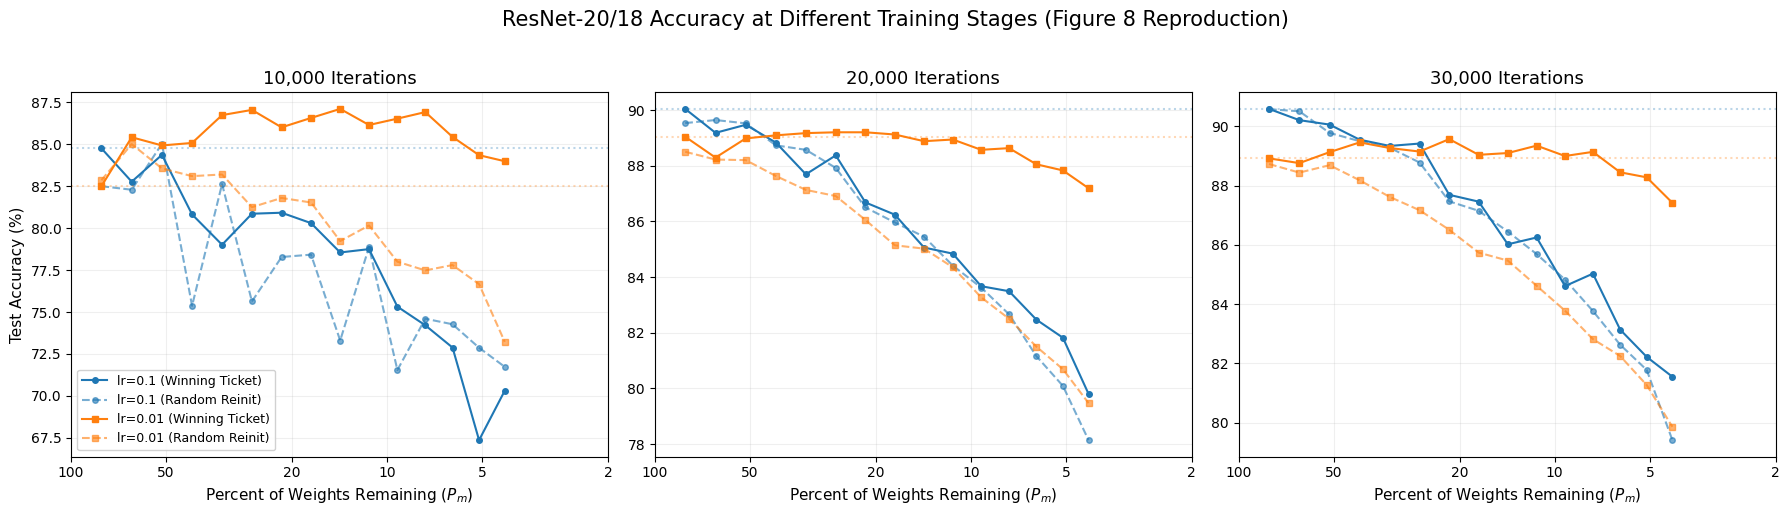

In [4]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 0. 定义路径 (保持你提供的路径)
# ==========================================
path_iter_01 = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"
path_rand_01 = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints/random_init_results__resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"

path_iter_001 = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.01_20260111_205802.pth"
path_rand_001 = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/random_init_results_matched.pth"

# 定义 Epoch 映射点 (假设总 Epoch=86)
# 10k iters approx epoch 29 (index 28)
# 20k iters approx epoch 57 (index 56)
# 30k iters is Final
EPOCH_INDICES = {
    '10k': 28, 
    '20k': 56, 
    '30k': -1 # Last one
}

# ==========================================
# 1. 健壮的数据提取函数
# ==========================================
def extract_history_acc(history, epoch_idx):
    """从 history 中提取指定 epoch 的准确率"""
    if history is None:
        return None
    
    # 尝试寻找准确率的 key
    acc_list = None
    possible_keys = ['test_accuracy', 'test_acc', 'val_accuracy', 'val_acc', 'accuracy', 'acc']
    
    if isinstance(history, dict):
        for k in possible_keys:
            if k in history:
                acc_list = history[k]
                break
    elif isinstance(history, list):
        acc_list = history # 假设它本身就是 list
        
    if acc_list is None or len(acc_list) == 0:
        return None
        
    # 处理索引越界 (比如训练提前停止)
    if epoch_idx == -1:
        return acc_list[-1]
    if epoch_idx >= len(acc_list):
        return acc_list[-1]
    
    return acc_list[epoch_idx]

def load_data_at_step(path, step_name):
    """加载指定文件在特定 step (10k/20k/30k) 的数据"""
    if not os.path.exists(path):
        print(f"File not found: {path}")
        return [], []
        
    checkpoint = torch.load(path, map_location='cpu')
    results = checkpoint['results'] if isinstance(checkpoint, dict) and 'results' in checkpoint else checkpoint
    
    x_list = []
    y_list = []
    
    target_idx = EPOCH_INDICES[step_name]
    
    for res in results:
        pct = res.get('remaining_params_pct', None)
        
        # 优先从 history 提取中间结果
        if step_name == '30k':
            # 30k 直接用最终结果即可 (res['test_accuracy'])
            acc = res.get('test_accuracy', None)
        else:
            # 10k, 20k 需要查 history
            acc = extract_history_acc(res.get('history'), target_idx)
            
        if pct is not None and acc is not None:
            x_list.append(pct)
            y_list.append(acc)
            
    return np.array(x_list), np.array(y_list)

# ==========================================
# 2. 绘图主逻辑
# ==========================================
steps = ['10k', '20k', '30k']
titles = ['10,000 Iterations', '20,000 Iterations', '30,000 Iterations']

# 创建 1行3列 的画布
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 统一的样式设置
color_01 = 'tab:blue'
color_001 = 'tab:orange'

for i, step in enumerate(steps):
    ax = axes[i]
    print(f"Plotting {step}...")
    
    # --- 加载该 Step 的数据 ---
    # LR 0.1
    x_iter_01, y_iter_01 = load_data_at_step(path_iter_01, step)
    x_rand_01, y_rand_01 = load_data_at_step(path_rand_01, step)
    
    # LR 0.01
    x_iter_001, y_iter_001 = load_data_at_step(path_iter_001, step)
    x_rand_001, y_rand_001 = load_data_at_step(path_rand_001, step)
    
    # --- 绘图 ---
    # LR 0.1
    if len(x_iter_01) > 0:
        ax.plot(x_iter_01, y_iter_01, label='lr=0.1 (Winning Ticket)', color=color_01, linestyle='-', marker='o', markersize=4)
        ax.axhline(y=y_iter_01[0], color=color_01, linestyle=':', alpha=0.3) # Baseline
    if len(x_rand_01) > 0:
        ax.plot(x_rand_01, y_rand_01, label='lr=0.1 (Random Reinit)', color=color_01, linestyle='--', marker='o', markersize=4, alpha=0.6)
        
    # LR 0.01
    if len(x_iter_001) > 0:
        ax.plot(x_iter_001, y_iter_001, label='lr=0.01 (Winning Ticket)', color=color_001, linestyle='-', marker='s', markersize=4)
        ax.axhline(y=y_iter_001[0], color=color_001, linestyle=':', alpha=0.3) # Baseline
    if len(x_rand_001) > 0:
        ax.plot(x_rand_001, y_rand_001, label='lr=0.01 (Random Reinit)', color=color_001, linestyle='--', marker='s', markersize=4, alpha=0.6)

    # --- 坐标轴美化 ---
    ax.set_xscale('log')
    ax.invert_xaxis() # 100 -> 1
    
    # 设置刻度
    ticks = [100, 50, 20, 10, 5, 2]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.minorticks_off()
    
    ax.set_xlabel('Percent of Weights Remaining ($P_m$)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Test Accuracy (%)', fontsize=11)
        
    ax.set_title(titles[i], fontsize=13)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    # 统一 Y 轴范围 (可选，防止跳变太大)
    # ax.set_ylim(bottom=10) 

# 只在第一个图显示图例，避免拥挤
axes[0].legend(loc='lower left', fontsize=9, framealpha=0.9)

plt.suptitle('ResNet-20/18 Accuracy at Different Training Stages (Figure 8 Reproduction)', fontsize=15, y=1.02)
plt.tight_layout()

# 保存
# save_path_combined = "reproduced_figure_8_evolution.png"
# 如果你有 fig_dir 变量，可以拼接
save_path_combined = os.path.join(fig_dir, f"reproduced_figure_8_evolution_{run_id}.png")

plt.savefig(save_path_combined, dpi=300, bbox_inches='tight')
print(f"Saved combined plot to {save_path_combined}")
plt.show()

Plotting 10k...
Plotting 20k...
Plotting 30k...
Saved complete plot to ../../results/resnet20_create_figures_20260112_102540/figures/reproduced_figure_8_complete_resnet20_create_figures_20260112_102540.png


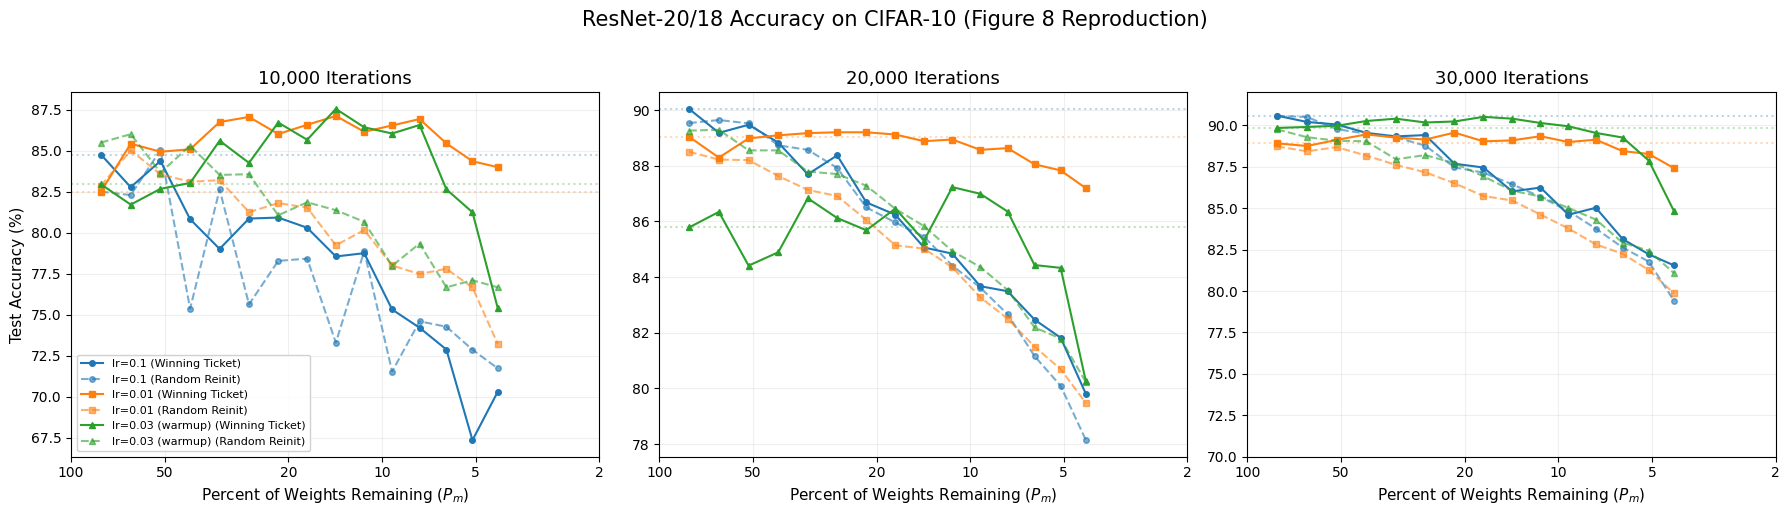

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 0. 定义路径 (根据你的文件名更新)
# ==========================================
# 1. LR = 0.1 (Standard, Blue)
path_iter_01 = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"
path_rand_01 = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints/random_init_results__resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"

# 2. LR = 0.01 (Low LR, Orange)
path_iter_001 = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.01_20260111_205802.pth"
path_rand_001 = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/random_init_results_matched.pth"

# 3. LR = 0.03 + Warmup (Proposed, Green) -> NEW!
# 假设这些文件在相同的目录下，或者你需要调整前面的路径
# 注意：这里我拼接了你提供的文件名，请检查文件夹路径是否正确
base_dir_warmup = "../../results/resnet20_iterative_random_init_LR_0.03_warmup_20260112_105110/checkpoints/"
path_iter_warmup = os.path.join(base_dir_warmup, "iterative_pruning_results_resnet20_iterative_random_init_LR_0.03_warmup_20260112_105110.pth")
path_rand_warmup = os.path.join(base_dir_warmup, "random_init_results__resnet20_iterative_random_init_LR_0.03_warmup_20260112_105110.pth")

# 定义 Epoch 映射点 (假设总 Epoch=86)
# 10k iters approx epoch 29 (index 28)
# 20k iters approx epoch 57 (index 56)
# 30k iters is Final
EPOCH_INDICES = {
    '10k': 28, 
    '20k': 56, 
    '30k': -1 # Last one
}

# ==========================================
# 1. 健壮的数据提取函数
# ==========================================
def extract_history_acc(history, epoch_idx):
    """从 history 中提取指定 epoch 的准确率"""
    if history is None:
        return None
    
    # 尝试寻找准确率的 key
    acc_list = None
    possible_keys = ['test_accuracy', 'test_acc', 'val_accuracy', 'val_acc', 'accuracy', 'acc']
    
    if isinstance(history, dict):
        for k in possible_keys:
            if k in history:
                acc_list = history[k]
                break
    elif isinstance(history, list):
        acc_list = history 
        
    if acc_list is None or len(acc_list) == 0:
        return None
        
    if epoch_idx == -1:
        return acc_list[-1]
    if epoch_idx >= len(acc_list):
        return acc_list[-1]
    
    return acc_list[epoch_idx]

def load_data_at_step(path, step_name):
    """加载指定文件在特定 step (10k/20k/30k) 的数据"""
    if not os.path.exists(path):
        print(f"Warning: File not found: {path}")
        return [], []
        
    try:
        checkpoint = torch.load(path, map_location='cpu')
        results = checkpoint['results'] if isinstance(checkpoint, dict) and 'results' in checkpoint else checkpoint
        
        x_list = []
        y_list = []
        
        target_idx = EPOCH_INDICES[step_name]
        
        for res in results:
            pct = res.get('remaining_params_pct', None)
            
            # 优先从 history 提取中间结果
            if step_name == '30k':
                acc = res.get('test_accuracy', None)
            else:
                acc = extract_history_acc(res.get('history'), target_idx)
                
            if pct is not None and acc is not None:
                x_list.append(pct)
                y_list.append(acc)
                
        return np.array(x_list), np.array(y_list)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return [], []

# ==========================================
# 2. 绘图主逻辑
# ==========================================
steps = ['10k', '20k', '30k']
titles = ['10,000 Iterations', '20,000 Iterations', '30,000 Iterations']

# 创建 1行3列 的画布
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 统一的样式设置
color_01 = 'tab:blue'      # LR=0.1
color_001 = 'tab:orange'   # LR=0.01
color_warmup = 'tab:green' # LR=0.03 + Warmup

for i, step in enumerate(steps):
    ax = axes[i]
    print(f"Plotting {step}...")
    
    # --- 1. 加载数据 ---
    # LR 0.1
    x_iter_01, y_iter_01 = load_data_at_step(path_iter_01, step)
    x_rand_01, y_rand_01 = load_data_at_step(path_rand_01, step)
    
    # LR 0.01
    x_iter_001, y_iter_001 = load_data_at_step(path_iter_001, step)
    x_rand_001, y_rand_001 = load_data_at_step(path_rand_001, step)
    
    # LR 0.03 Warmup
    x_iter_warm, y_iter_warm = load_data_at_step(path_iter_warmup, step)
    x_rand_warm, y_rand_warm = load_data_at_step(path_rand_warmup, step)
    
    # --- 2. 绘图 ---
    
    # LR 0.1 (Blue)
    if len(x_iter_01) > 0:
        ax.plot(x_iter_01, y_iter_01, label='lr=0.1 (Winning Ticket)', color=color_01, linestyle='-', marker='o', markersize=4)
        # 画 Baseline (虚线, 只画一次)
        ax.axhline(y=y_iter_01[0], color=color_01, linestyle=':', alpha=0.3) 
    if len(x_rand_01) > 0:
        ax.plot(x_rand_01, y_rand_01, label='lr=0.1 (Random Reinit)', color=color_01, linestyle='--', marker='o', markersize=4, alpha=0.6)
        
    # LR 0.01 (Orange)
    if len(x_iter_001) > 0:
        ax.plot(x_iter_001, y_iter_001, label='lr=0.01 (Winning Ticket)', color=color_001, linestyle='-', marker='s', markersize=4)
        ax.axhline(y=y_iter_001[0], color=color_001, linestyle=':', alpha=0.3)
    if len(x_rand_001) > 0:
        ax.plot(x_rand_001, y_rand_001, label='lr=0.01 (Random Reinit)', color=color_001, linestyle='--', marker='s', markersize=4, alpha=0.6)

    # LR 0.03 Warmup (Green)
    if len(x_iter_warm) > 0:
        ax.plot(x_iter_warm, y_iter_warm, label='lr=0.03 (warmup) (Winning Ticket)', color=color_warmup, linestyle='-', marker='^', markersize=4)
        ax.axhline(y=y_iter_warm[0], color=color_warmup, linestyle=':', alpha=0.3)
    if len(x_rand_warm) > 0:
        ax.plot(x_rand_warm, y_rand_warm, label='lr=0.03 (warmup) (Random Reinit)', color=color_warmup, linestyle='--', marker='^', markersize=4, alpha=0.6)

    # --- 3. 坐标轴美化 ---
    ax.set_xscale('log')
    ax.invert_xaxis() # 100 -> 1
    
    # 设置刻度
    ticks = [100, 50, 20, 10, 5, 2]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.minorticks_off()
    
    ax.set_xlabel('Percent of Weights Remaining ($P_m$)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Test Accuracy (%)', fontsize=11)
        
    ax.set_title(titles[i], fontsize=13)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    # 设置 Y 轴范围 (可选，让图看起来更整齐)
    # 对于 30k 图，范围通常在 70-92 之间
    if i == 2:
        ax.set_ylim(bottom=70, top=92) 

# 只在第一个图显示图例，避免拥挤，位置设为 'lower left'
axes[0].legend(loc='lower left', fontsize=8, framealpha=0.9)

plt.suptitle('ResNet-20/18 Accuracy on CIFAR-10 (Figure 8 Reproduction)', fontsize=15, y=1.02)
plt.tight_layout()

# 保存
save_path_combined = os.path.join(fig_dir, f"reproduced_figure_8_complete_{run_id}.png")
# save_path_combined = "reproduced_figure_8_complete.png" # 如果没有 fig_dir 变量

plt.savefig(save_path_combined, dpi=300, bbox_inches='tight')
print(f"Saved complete plot to {save_path_combined}")
plt.show()

Plotting 10k...
Plotting 20k...
Plotting 30k...
Saved complete plot to ../../results/resnet20_create_figures_20260112_102540/figures/reproduced_figure_8_complete_adjusted_resnet20_create_figures_20260112_102540.png


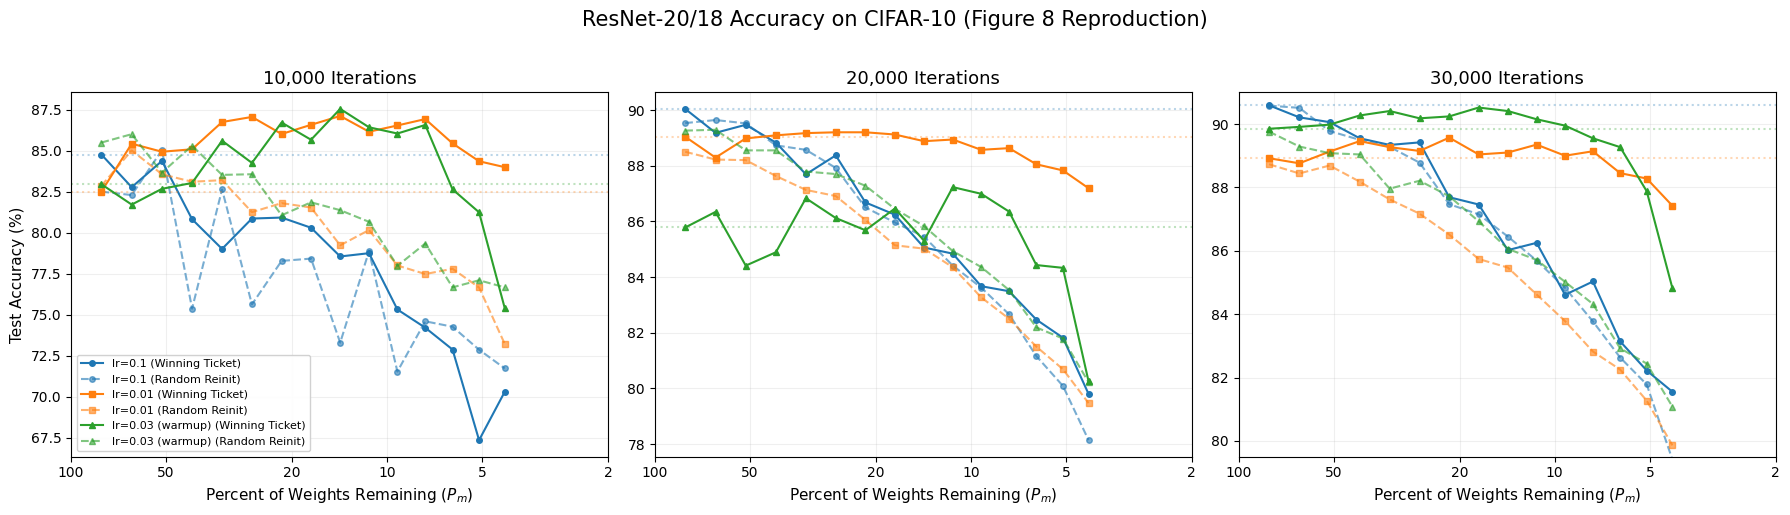

In [9]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

# ==========================================
# 0. 定义路径 (已更新 Warmup 路径)
# ==========================================
# 1. LR = 0.1 (Standard, Blue)
path_iter_01 = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"
path_rand_01 = "../../results/resnet20_iterative_random_init_LR_0.1_20260112_025542/checkpoints/random_init_results__resnet20_iterative_random_init_LR_0.1_20260112_025542.pth"

# 2. LR = 0.01 (Low LR, Orange)
path_iter_001 = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/iterative_pruning_results_resnet20_iterative_random_init_LR_0.01_20260111_205802.pth"
path_rand_001 = "../../results/resnet20_iterative_random_init_LR_0.01_20260111_205802/checkpoints/random_init_results_matched.pth"

# 3. LR = 0.03 + Warmup (Proposed, Green) -> Updated!
# 假设目录结构与之前一致，只是文件名变了
base_dir_warmup = "../../results/resnet20_iterative_random_init_LR_0.03_warmup_20260112_105110/checkpoints/"
path_iter_warmup = os.path.join(base_dir_warmup, "iterative_pruning_results_resnet20_iterative_random_init_LR_0.03_warmup_20260112_105110.pth")
path_rand_warmup = os.path.join(base_dir_warmup, "random_init_results__resnet20_iterative_random_init_LR_0.03_warmup_20260112_105110.pth")

# 定义 Epoch 映射点
EPOCH_INDICES = {
    '10k': 28, 
    '20k': 56, 
    '30k': -1 # Last one
}

# ==========================================
# 1. 数据提取函数 (保持不变)
# ==========================================
def extract_history_acc(history, epoch_idx):
    if history is None: return None
    acc_list = None
    possible_keys = ['test_accuracy', 'test_acc', 'val_accuracy', 'val_acc', 'accuracy', 'acc']
    
    if isinstance(history, dict):
        for k in possible_keys:
            if k in history:
                acc_list = history[k]; break
    elif isinstance(history, list):
        acc_list = history
        
    if acc_list is None or len(acc_list) == 0: return None
    if epoch_idx == -1: return acc_list[-1]
    if epoch_idx >= len(acc_list): return acc_list[-1]
    return acc_list[epoch_idx]

def load_data_at_step(path, step_name):
    if not os.path.exists(path):
        print(f"Warning: File not found: {path}")
        return [], []
    try:
        checkpoint = torch.load(path, map_location='cpu')
        results = checkpoint['results'] if isinstance(checkpoint, dict) and 'results' in checkpoint else checkpoint
        
        x_list, y_list = [], []
        target_idx = EPOCH_INDICES[step_name]
        
        for res in results:
            pct = res.get('remaining_params_pct', None)
            if step_name == '30k':
                acc = res.get('test_accuracy', None)
            else:
                acc = extract_history_acc(res.get('history'), target_idx)
                
            if pct is not None and acc is not None:
                x_list.append(pct)
                y_list.append(acc)
        return np.array(x_list), np.array(y_list)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return [], []

# ==========================================
# 2. 绘图主逻辑 (已调整 Y 轴范围)
# ==========================================
steps = ['10k', '20k', '30k']
titles = ['10,000 Iterations', '20,000 Iterations', '30,000 Iterations']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

color_01 = 'tab:blue'      # LR=0.1
color_001 = 'tab:orange'   # LR=0.01
color_warmup = 'tab:green' # LR=0.03 + Warmup

for i, step in enumerate(steps):
    ax = axes[i]
    print(f"Plotting {step}...")
    
    # 加载数据
    x_iter_01, y_iter_01 = load_data_at_step(path_iter_01, step)
    x_rand_01, y_rand_01 = load_data_at_step(path_rand_01, step)
    
    x_iter_001, y_iter_001 = load_data_at_step(path_iter_001, step)
    x_rand_001, y_rand_001 = load_data_at_step(path_rand_001, step)
    
    x_iter_warm, y_iter_warm = load_data_at_step(path_iter_warmup, step)
    x_rand_warm, y_rand_warm = load_data_at_step(path_rand_warmup, step)
    
    # 绘图 - LR 0.1
    if len(x_iter_01) > 0:
        ax.plot(x_iter_01, y_iter_01, label='lr=0.1 (Winning Ticket)', color=color_01, linestyle='-', marker='o', markersize=4)
        ax.axhline(y=y_iter_01[0], color=color_01, linestyle=':', alpha=0.3) 
    if len(x_rand_01) > 0:
        ax.plot(x_rand_01, y_rand_01, label='lr=0.1 (Random Reinit)', color=color_01, linestyle='--', marker='o', markersize=4, alpha=0.6)
        
    # 绘图 - LR 0.01
    if len(x_iter_001) > 0:
        ax.plot(x_iter_001, y_iter_001, label='lr=0.01 (Winning Ticket)', color=color_001, linestyle='-', marker='s', markersize=4)
        ax.axhline(y=y_iter_001[0], color=color_001, linestyle=':', alpha=0.3)
    if len(x_rand_001) > 0:
        ax.plot(x_rand_001, y_rand_001, label='lr=0.01 (Random Reinit)', color=color_001, linestyle='--', marker='s', markersize=4, alpha=0.6)

    # 绘图 - LR 0.03 Warmup
    if len(x_iter_warm) > 0:
        ax.plot(x_iter_warm, y_iter_warm, label='lr=0.03 (warmup) (Winning Ticket)', color=color_warmup, linestyle='-', marker='^', markersize=4)
        ax.axhline(y=y_iter_warm[0], color=color_warmup, linestyle=':', alpha=0.3)
    if len(x_rand_warm) > 0:
        ax.plot(x_rand_warm, y_rand_warm, label='lr=0.03 (warmup) (Random Reinit)', color=color_warmup, linestyle='--', marker='^', markersize=4, alpha=0.6)

    # 坐标轴美化
    ax.set_xscale('log')
    ax.invert_xaxis()
    
    ticks = [100, 50, 20, 10, 5, 2]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.minorticks_off()
    
    ax.set_xlabel('Percent of Weights Remaining ($P_m$)', fontsize=11)
    if i == 0:
        ax.set_ylabel('Test Accuracy (%)', fontsize=11)
        
    ax.set_title(titles[i], fontsize=13)
    ax.grid(True, which="both", ls="-", alpha=0.2)
    
    # === [关键修改] 调整 30k 图的 Y 轴范围 ===
    if i == 2:  # 30k Iterations
        ax.set_ylim(bottom=79.5, top=91) # 适配你的数据，重点展示 77.5% - 92% 区间

# 图例设置
axes[0].legend(loc='lower left', fontsize=8, framealpha=0.9)

plt.suptitle('ResNet-20/18 Accuracy on CIFAR-10 (Figure 8 Reproduction)', fontsize=15, y=1.02)
plt.tight_layout()

# 保存
save_name = "reproduced_figure_8_complete_adjusted.png"
if 'fig_dir' in globals() and 'run_id' in globals():
    save_path = os.path.join(fig_dir, f"reproduced_figure_8_complete_adjusted_{run_id}.png")
else:
    save_path = save_name

plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Saved complete plot to {save_path}")
plt.show()